# Saved SAE Loss Curves

Training metrics are saved under `saved_saes/**/metrics.json`. This notebook focuses on `saved_saes/**/best_step_update/metrics.json`, which are the metric histories attached to each best-step checkpoint, and plots loss over training step for each saved SAE.

In [1]:
from collections import defaultdict
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SAVED_SAE_ROOT = PROJECT_ROOT / "saved_saes"
BEST_STEP_ONLY = True

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def discover_metric_paths(root: Path, best_step_only: bool = True) -> list[Path]:
    paths = sorted(root.glob("**/metrics.json"))
    if best_step_only:
        paths = [path for path in paths if path.parent.name == "best_step_update"]
    return paths


def label_for_metrics_path(path: Path, root: Path) -> str:
    rel = path.relative_to(root)
    parts = rel.parts
    if "best_step_update" in parts:
        parts = parts[:parts.index("best_step_update")]
    else:
        parts = parts[:-1]
    return "/".join(parts)


def load_metrics(path: Path, root: Path) -> list[dict]:
    label = label_for_metrics_path(path, root)
    metrics = json.loads(path.read_text(encoding="utf-8"))
    rows = []
    for step, metric in enumerate(metrics, start=1):
        row = {key: float(value) for key, value in metric.items() if isinstance(value, (int, float))}
        row["step"] = step
        row["sae"] = label
        row["metrics_path"] = str(path.relative_to(PROJECT_ROOT))
        rows.append(row)
    return rows


metric_paths = discover_metric_paths(SAVED_SAE_ROOT, best_step_only=BEST_STEP_ONLY)
if not metric_paths:
    raise FileNotFoundError(f"No metrics.json files found under {SAVED_SAE_ROOT}")

rows = [row for path in metric_paths for row in load_metrics(path, SAVED_SAE_ROOT)]
by_sae = defaultdict(list)
for row in rows:
    by_sae[row["sae"]].append(row)

print(f"Loaded {len(rows):,} metric rows from {len(metric_paths)} best-step SAE metric files.")
for path in metric_paths:
    print(path.relative_to(PROJECT_ROOT))

Loaded 464,400 metric rows from 5 best-step SAE metric files.
saved_saes/relu_mid_1/relu/best_step_update/metrics.json
saved_saes/shrink_mid_1/shrink/best_step_update/metrics.json
saved_saes/topbottomk_mid_1/topbottomk/best_step_update/metrics.json
saved_saes/topbottomk_mid_1_1/topbottomk/best_step_update/metrics.json
saved_saes/topk_mid_1/topk/best_step_update/metrics.json


In [3]:
summary_rows = []
for sae, sae_rows in sorted(by_sae.items()):
    last = sae_rows[-1]
    saved_steps = [row["step"] for row in sae_rows if row.get("saved_step_update_checkpoint") == 1.0]
    summary_rows.append(
        {
            "sae": sae,
            "steps": len(sae_rows),
            "last_loss": last.get("loss", float("nan")),
            "min_loss": min(row["loss"] for row in sae_rows if "loss" in row),
            "last_update_avg_loss": last.get("update_avg_loss", float("nan")),
            "best_step_update_step": saved_steps[-1] if saved_steps else None,
        }
    )

columns = ["sae", "steps", "last_loss", "min_loss", "last_update_avg_loss", "best_step_update_step"]
formats = {
    "steps": lambda value: f"{int(value):,}",
    "last_loss": lambda value: f"{value:,.3f}",
    "min_loss": lambda value: f"{value:,.3f}",
    "last_update_avg_loss": lambda value: f"{value:,.3f}",
    "best_step_update_step": lambda value: "" if value is None else f"{int(value):,}",
}

def format_value(column: str, value) -> str:
    return formats.get(column, str)(value)

table = [[format_value(column, row[column]) for column in columns] for row in summary_rows]
widths = [max(len(column), *(len(row[index]) for row in table)) for index, column in enumerate(columns)]
print(" | ".join(column.ljust(widths[index]) for index, column in enumerate(columns)))
print("-+-".join("-" * width for width in widths))
for row in table:
    print(" | ".join(value.ljust(widths[index]) for index, value in enumerate(row)))

sae                           | steps  | last_loss  | min_loss  | last_update_avg_loss | best_step_update_step
------------------------------+--------+------------+-----------+----------------------+----------------------
relu_mid_1/relu               | 96,800 | 2,279.699  | 2,172.224 | 2,284.348            | 96,800               
shrink_mid_1/shrink           | 87,600 | 80,978.117 | 2,806.669 | 80,839.292           | 87,600               
topbottomk_mid_1/topbottomk   | 85,600 | 61,891.031 | 2,008.846 | 62,598.565           | 85,600               
topbottomk_mid_1_1/topbottomk | 97,200 | 596.992    | 533.945   | 581.885              | 97,200               
topk_mid_1/topk               | 97,200 | 721.337    | 340.109   | 703.099              | 97,200               


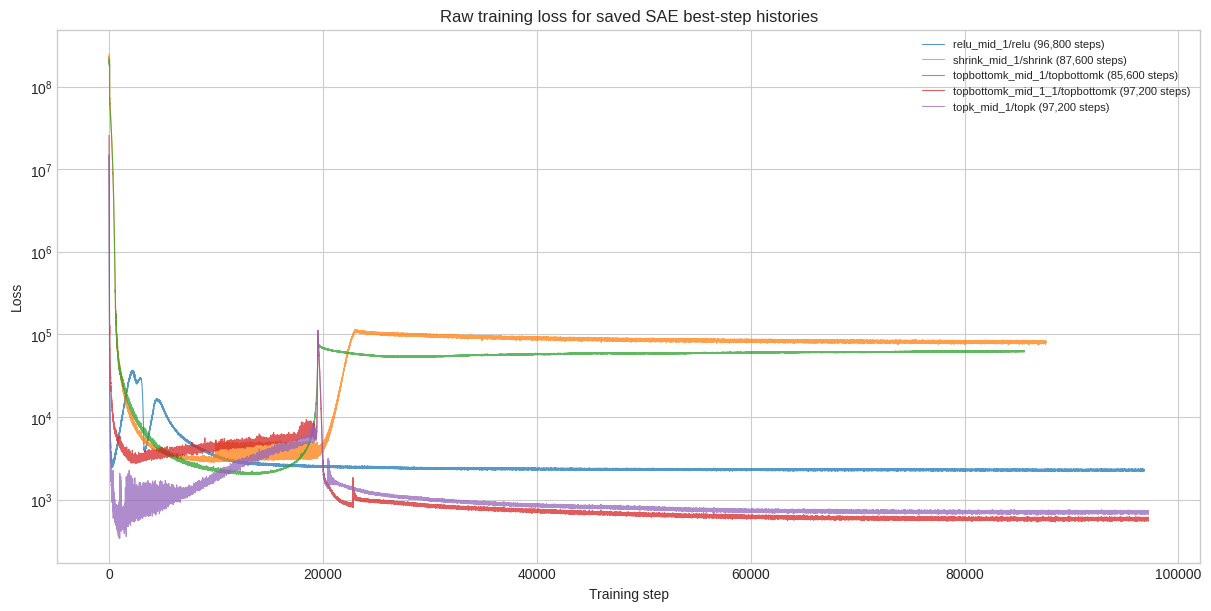

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

for sae, sae_rows in sorted(by_sae.items()):
    steps = np.array([row["step"] for row in sae_rows])
    losses = np.array([row["loss"] for row in sae_rows])
    ax.plot(steps, losses, linewidth=0.8, alpha=0.75, label=f"{sae} ({len(sae_rows):,} steps)")

ax.set_title("Raw training loss for saved SAE best-step histories")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(loc="best", fontsize=8)
plt.show()

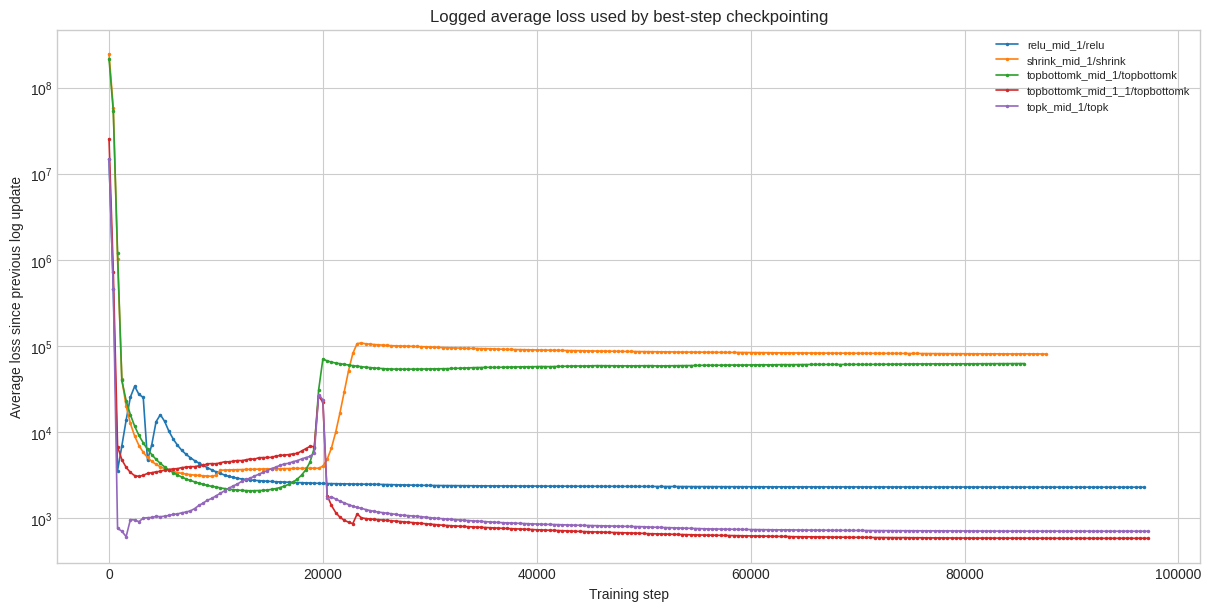

In [5]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

for sae, sae_rows in sorted(by_sae.items()):
    logged_rows = [row for row in sae_rows if "update_avg_loss" in row]
    if not logged_rows:
        continue
    steps = np.array([row["step"] for row in logged_rows])
    losses = np.array([row["update_avg_loss"] for row in logged_rows])
    ax.plot(steps, losses, marker=".", markersize=3, linewidth=1.2, label=sae)

ax.set_title("Logged average loss used by best-step checkpointing")
ax.set_xlabel("Training step")
ax.set_ylabel("Average loss since previous log update")
ax.set_yscale("log")
ax.legend(loc="best", fontsize=8)
plt.show()